In [215]:
import yaml
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from cobra.flux_analysis.parsimonious import optimize_minimal_flux

In [216]:
PRINT_DEMANDS = True
PLOT_BOUNDS = True

cell_type = "MCF7_core"

sbml_file = "../config/MCF7_Zielinski_2017_core.sbml"
model = read_sbml_model(sbml_file, f_replace={'F_REACTION': lambda x: x})
model.solver = "cplex"
exchanges = [r.id for r in model.exchanges if r.id.startswith("R_EX")]

for r in model.reactions:
    if r.objective_coefficient != 0:
        objective_reaction = r.id
        break

print(f"Objective reaction: {objective_reaction}")

model.reactions.R_DM_gudac_c_.upper_bound = 0.0
model.reactions.R_biomass_reaction.lower_bound = 0.0
model.reactions.R_biomass_reaction.upper_bound = 0.05
model.reactions.R_DM_atp_c_.lower_bound = 0.0
model.reactions.R_DM_atp_c_.upper_bound = 100
model.reactions.R_ATPM.lower_bound = 1.07

model.reactions.R_EX_ala_L_e.upper_bound = 0.0
model.reactions.R_EX_cit_e.upper_bound   = 0.0
model.reactions.R_EX_pro_L_e.upper_bound = 0.0
model.reactions.R_EX_pro_L_e.lower_bound = 0.0
model.reactions.R_EX_ala_L_e.lower_bound = 0.0 # 0.000000
model.reactions.R_EX_mal_L_e.upper_bound = 0.0 # 0.000399
model.reactions.R_EX_cit_e.upper_bound   = 0.0 # 0.002172

model.reactions.R_EX_urea_e.upper_bound  = 0.0 # 0.002634
model.reactions.R_EX_nh4_e.upper_bound   = 100.0 # 0.022598

if PRINT_DEMANDS:
    print("- Demand reactions")
    print(model.reactions.R_DM_atp_c_.reaction)
    print(model.reactions.R_DM_nadph__91__c__93__.reaction)
    print(model.reactions.R_DM_nadph__91__m__93__.reaction)
    print(model.reactions.R_DM_nadh_trans__91__m__93__.reaction)
    print()


if PLOT_BOUNDS:
    print("- Reaction bounds to consider")
    for r in model.reactions:
        if r.bounds[0] > 0:
            print(r.id, r.bounds)
            continue
        if r.bounds[1] < 0:
            print(r.id, r.bounds)
            continue

    for r in model.exchanges:
        if r.lower_bound < 0:
            print(r.id, r.bounds)
            continue
        if r.upper_bound < 0:
            print(r.id, r.bounds)
            continue
        if r.lower_bound > 0:
            print(r.id, r.bounds)
            continue   
    print()

solution = model.optimize()
print()
summary = None
if solution.status == 'optimal':
    summary = model.summary(solution)
    max_growth_rate = solution.objective_value
    print(f"Max growth rate: {max_growth_rate} 1/hr")
else:
    print("infeasible model")
summary

Objective reaction: R_biomass_reaction
- Demand reactions
M_atp_c + M_h2o_c --> M_adp_c + M_h_c + M_pi_c
M_nadph_c --> M_h_c + M_nadp_c
M_nadph_m --> M_h_m + M_nadp_m
M_nadh_m + M_nadp_m --> M_nad_m + M_nadph_m

- Reaction bounds to consider
R_ATPM (1.07, 1000.0)
R_EX_arg_L_e (-0.0101373438224108, 0.0)
R_EX_asn_L_e (-0.00583359256589797, 0.0)
R_EX_asp_L_e (-0.00959405479991621, 0.0)
R_EX_chol_e (-1000.0, 1000.0)
R_EX_cl_e (-1000.0, 1000.0)
R_EX_glc_e (-0.288633977201338, 0.0)
R_EX_gln_L_e (-0.0878815507948709, 0.0)
R_EX_glu_L_e (-0.00669482376697556, 0.0)
R_EX_gly_e (-0.00738205614816154, 0.0)
R_EX_h_e (-1000.0, 1000.0)
R_EX_h2o_e (-1000.0, 1000.0)
R_EX_ile_L_e (-0.0212556395653472, 0.0)
R_EX_k_e (-1000.0, 1000.0)
R_EX_leu_L_e (-0.0226239513340666, 0.0)
R_EX_lys_L_e (-0.0188433023673326, 0.0)
R_EX_na1_e (-1000.0, 1000.0)
R_EX_nh4_e (-1000.0, 100.0)
R_EX_o2_e (-18.0, 0.0)
R_EX_orn_e (-0.000901866820618997, 0.0)
R_EX_phe_L_e (-0.00590380298884837, 0.0)
R_EX_pi_e (-1000.0, 1000.0)
R_EX_se

Metabolite,Reaction,Flux,C-Number,C-Flux
M_Tyr_ggn_c,R_DM_Tyr_ggn_c_,0.0009189,0,0.00%
M_gudac_c,R_DM_gudac_c_,0.009592,3,1.04%
M_arg_L_e,R_EX_arg_L_e,0.0006004,6,0.13%
M_asn_L_e,R_EX_asn_L_e,0.005834,4,0.84%
M_asp_L_e,R_EX_asp_L_e,0.009594,4,1.38%
M_chol_e,R_EX_chol_e,0.0009479,5,0.17%
M_glc_D_e,R_EX_glc_e,0.2531,6,54.71%
M_gln_L_e,R_EX_gln_L_e,0.08788,5,15.83%
M_glu_L_e,R_EX_glu_L_e,0.006695,5,1.21%
M_gly_e,R_EX_gly_e,0.007382,2,0.53%


In [217]:
DEFAULT_UPTAKE_BOUND = -0.02
DEFAULT_SECRETION_BOUND = 1000.0

for r in model.exchanges:
    if r.upper_bound > 0:
        r.upper_bound = DEFAULT_SECRETION_BOUND
    if r.lower_bound < 0:
        r.lower_bound = DEFAULT_UPTAKE_BOUND


model.reactions.R_EX_o2_e.lower_bound  = -0.05
model.reactions.R_EX_glc_e.lower_bound = -0.5
model.reactions.R_EX_gln_L_e.lower_bound = -0.1


model.reactions.R_EX_lac_L_e.upper_bound = 100

model.reactions.R_biomass_reaction.lower_bound = 0.0
model.reactions.R_biomass_reaction.upper_bound = 0.05

print()
solution = model.optimize()

print()
summary = None
if solution.status == 'optimal':
    summary = model.summary(solution)
    max_growth_rate = solution.objective_value
    print(f"Max growth rate: {max_growth_rate} 1/hr")
else:
    print("infeasible model")
summary





Max growth rate: 0.00377593844091463 1/hr


Metabolite,Reaction,Flux,C-Number,C-Flux
M_Tyr_ggn_c,R_DM_Tyr_ggn_c_,0.0001295,0,0.00%
M_gudac_c,R_DM_gudac_c_,0.001436,3,0.13%
M_asn_L_e,R_EX_asn_L_e,0.002276,4,0.28%
M_chol_e,R_EX_chol_e,0.0001335,5,0.02%
M_glc_D_e,R_EX_glc_e,0.5,6,93.41%
M_gln_L_e,R_EX_gln_L_e,0.002802,5,0.44%
M_gly_e,R_EX_gly_e,0.02,2,1.25%
M_ile_L_e,R_EX_ile_L_e,0.001208,6,0.23%
M_leu_L_e,R_EX_leu_L_e,0.002072,6,0.39%
M_lys_L_e,R_EX_lys_L_e,0.002087,6,0.39%


In [218]:
print("Running FVA...")
fva_df = flux_variability_analysis(model, processes=10, fraction_of_optimum=0.0)

fva_ex_df = fva_df.filter(regex='^R_EX', axis=0)

eps = 1e-9
mask = fva_ex_df.abs().max(axis=1) < eps
to_remove = fva_ex_df.index[mask]
print(f"trimming {len(to_remove)} bloecked reactions")
print(to_remove)
model.remove_reactions(to_remove)

Running FVA...
trimming 8 bloecked reactions
Index(['R_EX_ala_L_e', 'R_EX_cit_e', 'R_EX_cl_e', 'R_EX_k_e', 'R_EX_na1_e',
       'R_EX_pro_L_e', 'R_EX_urea_e', 'R_EX_mal_L_e'],
      dtype='object')


In [219]:
sbml_out = "../config/MCF7_Zielinski_2017_core_trimmed.sbml"
write_sbml_model(model, sbml_out, f_replace=None)

infeasible model


/home/mponce/projects/devel/PhysiCelldFBA/venv/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


array([[-1.00000000e-01,  9.00498842e-03],
       [-9.94974874e-02,  8.95317407e-03],
       [-9.89949749e-02,  8.90135972e-03],
       [-9.84924623e-02,  8.84954537e-03],
       [-9.79899497e-02,  8.79773102e-03],
       [-9.74874372e-02,  8.74591667e-03],
       [-9.69849246e-02,  8.69410232e-03],
       [-9.64824121e-02,  8.64228797e-03],
       [-9.59798995e-02,  8.59047362e-03],
       [-9.54773869e-02,  8.53865928e-03],
       [-9.49748744e-02,  8.48684493e-03],
       [-9.44723618e-02,  8.43503058e-03],
       [-9.39698492e-02,  8.38321623e-03],
       [-9.34673367e-02,  8.33140188e-03],
       [-9.29648241e-02,  8.27958753e-03],
       [-9.24623116e-02,  8.22777318e-03],
       [-9.19597990e-02,  8.17595883e-03],
       [-9.14572864e-02,  8.12414448e-03],
       [-9.09547739e-02,  8.07156914e-03],
       [-9.04522613e-02,  8.01886201e-03],
       [-8.99497487e-02,  7.96615488e-03],
       [-8.94472362e-02,  7.91344776e-03],
       [-8.89447236e-02,  7.86074063e-03],
       [-8.

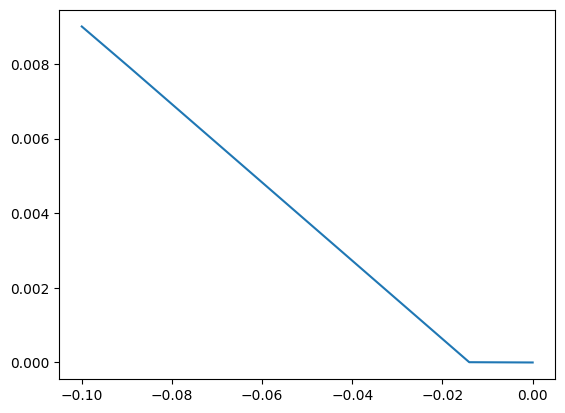

In [220]:
n = 200
res = np.zeros((n,2))
for i,lb in enumerate(np.linspace(-0.1, 0.0, n)):

    model.reactions.R_EX_o2_e.lower_bound  = lb
    solution = model.optimize()
    if solution.status == 'optimal':

        res[i,0] = lb
        res[i,1] = solution.objective_value
    else:
        print("infeasible model")
        break

plt.plot(res[:,0],res[:,1])

res[res[:,1]>=0,:]